In [6]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from itertools import combinations

from scipy import stats

In [7]:
quant_2 = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Python_Projects\QVI_data.csv")
quant_2_copied = quant_2
quant_2_copied.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,KETTLE,MIDAGE SINGLES/COUPLES,Budget


In [8]:
# Create YEARMONTH Column
quant_2_copied['DATE'] = pd.to_datetime(quant_2_copied['DATE'])
quant_2_copied['YEARMONTH'] = quant_2_copied['DATE'].dt.year * 100 + quant_2_copied['DATE'].dt.month

# Create Store Metrics

In [9]:
measureOverTime = quant_2_copied.groupby(['STORE_NBR','YEARMONTH']).agg(
    totSales = ('TOT_SALES','sum'),
    nCustomers = ('LYLTY_CARD_NBR','nunique'),
    nTxn = ('TXN_ID','count'),
    nChips = ('PROD_QTY','sum')
).reset_index()

# Additional metrics
measureOverTime['nTxnPerCust'] = measureOverTime['nTxn'] / measureOverTime['nCustomers']
measureOverTime['nChipsPerTxn'] = measureOverTime['nChips'] / measureOverTime['nTxn']
measureOverTime['avgPricePerUnit'] = measureOverTime['totSales'] / measureOverTime['nChips']

measureOverTime = measureOverTime.sort_values(['STORE_NBR', 'YEARMONTH'])

# Filter Pre-Trial Stores

In [ ]:
store_counts = measureOverTime.groupby('STORE_NBR')['YEARMONTH'].count()

storesWithFullObs = store_counts[store_counts == 12].index

preTrialMeasures = measureOverTime[
    (measureOverTime['YEARMONTH'] < 201902) &
    (measureOverTime['STORE_NBR'].isin(storesWithFullObs))
].copy()


print(f"Number of stores with full pre-trial observation: {len(storesWithFullObs)}")
print("\nPre-trial measures shape:", preTrialMeasures.shape)
print(preTrialMeasures)

#preTrialMeasures.to_csv('pre_trial_measures.csv', index=False)

Number of stores with full pre-trial observation: 259

Pre-trial measures shape: (1813, 9)
      STORE_NBR  YEARMONTH  totSales  nCustomers  nTxn  nChips  nTxnPerCust  \
0             1     201807     188.9          47    49      58     1.042553   
1             1     201808     168.4          41    41      52     1.000000   
2             1     201809     268.1          57    59      71     1.035088   
3             1     201810     175.4          39    40      51     1.025641   
4             1     201811     184.8          44    45      55     1.022727   
...         ...        ...       ...         ...   ...     ...          ...   
3155        272     201809     294.5          31    35      69     1.129032   
3156        272     201810     405.1          41    48      94     1.170732   
3157        272     201811     355.8          39    43      83     1.102564   
3158        272     201812     363.1          43    43      81     1.000000   
3159        272     201901     392.4    

# Correlation Function


In [11]:
def calculate_correlation(input_table: pd.DataFrame, 
                          metric_col: str, 
                          trial_store: int) -> pd.DataFrame:
    
    df = input_table.copy()
    
    
    all_stores = df['STORE_NBR'].unique()
    control_stores = [s for s in all_stores if s != trial_store]
    
    results = []
    
    trial_data = df[df['STORE_NBR'] == trial_store].sort_values('YEARMONTH')
    trial_values = trial_data[metric_col].values
    
    
    for ctrl_store in control_stores:
        ctrl_data = df[df['STORE_NBR'] == ctrl_store].sort_values('YEARMONTH')
        ctrl_values = ctrl_data[metric_col].values
        
        if len(trial_values) == len(ctrl_values) and len(trial_values) > 1:
            corr = np.corrcoef(trial_values, ctrl_values)[0, 1]
        else:
            corr = np.nan
        
        results.append({
            'Store1': trial_store,
            'Store2': ctrl_store,
            'corr_measure': corr
        })
    
    corr_table = pd.DataFrame(results)
    return corr_table
        
    

In [12]:
corr_sales_77 = calculate_correlation(
    input_table= preTrialMeasures, 
    metric_col='totSales', 
    trial_store=77
)

print("Correlation with Trial Store 77 (totSales):")
print(corr_sales_77.head(10))

Correlation with Trial Store 77 (totSales):
   Store1  Store2  corr_measure
0      77       1     -0.005382
1      77       2     -0.251183
2      77       3      0.660447
3      77       4     -0.347846
4      77       5     -0.139048
5      77       6      0.002087
6      77       7     -0.029185
7      77       8     -0.478238
8      77       9     -0.813285
9      77      10      0.483885


# Magnitude Distance Function

In [13]:
def calculate_magnitude_distance(input_table: pd.DataFrame, 
                                 metric_col: str, 
                                 trial_store: int) -> pd.DataFrame:
    
    df = input_table.copy()
    
    
    all_stores = df['STORE_NBR'].unique()
    
    
    records = []
    
    trial_data = df[df['STORE_NBR'] == trial_store].sort_values('YEARMONTH').copy()
    trial_data = trial_data.set_index('YEARMONTH')
    
    for ctrl_store in all_stores:
        if ctrl_store == trial_store:
            continue  # Skip the trial store itself
        
        ctrl_data = df[df['STORE_NBR'] == ctrl_store].sort_values('YEARMONTH').copy()
        ctrl_data = ctrl_data.set_index('YEARMONTH')
        
        common_months = trial_data.index.intersection(ctrl_data.index)
        
        
        if len(common_months) < 2:
            continue
        
        trial_vals = trial_data.loc[common_months, metric_col].values
        ctrl_vals = ctrl_data.loc[common_months, metric_col].values
        
        
        abs_diff = np.abs(trial_vals - ctrl_vals)
        
        for ym, diff in zip(common_months, abs_diff):
            records.append({
                'Store1': trial_store,
                'Store2': ctrl_store,
                'YEARMONTH': ym,
                'measure': diff
            })
            
            calc_dist_table = pd.DataFrame(records)
    
    if calc_dist_table.empty:
        return pd.DataFrame(columns=['Store1', 'Store2', 'mag_measure'])
    
    min_max = (
        calc_dist_table.groupby(['Store1', 'YEARMONTH'])['measure']
        .agg(minDist='min', maxDist='max')
        .reset_index()
    )
    
    dist_table = calc_dist_table.merge(min_max, on=['Store1', 'YEARMONTH'])
    
    dist_table['magnitudeMeasure'] = 1 - (dist_table['measure'] - dist_table['minDist']) / \
                                     (dist_table['maxDist'] - dist_table['minDist'])
    
    
    final_dist_table = (
        dist_table.groupby(['Store1', 'Store2'])['magnitudeMeasure']
        .mean()
        .reset_index()
        .rename(columns={'magnitudeMeasure': 'mag_measure'})
    )
    
    return final_dist_table
                                     
                                     
    
    

In [14]:
mag_sales_77 = calculate_magnitude_distance(
    input_table= preTrialMeasures, 
    metric_col='totSales', 
    trial_store=77
)

print("Magnitude Distance (totSales) for Trial Store 77:")
print(mag_sales_77.head(10))
print(f"Shape: {mag_sales_77.shape}")

Magnitude Distance (totSales) for Trial Store 77:
   Store1  Store2  mag_measure
0      77       1     0.953691
1      77       2     0.937207
2      77       3     0.345432
3      77       4     0.181068
4      77       5     0.565130
5      77       6     0.966970
6      77       7     0.372525
7      77       8     0.891997
8      77       9     0.918759
9      77      10     0.499636
Shape: (258, 3)


# Find Control Store for Trial Store 77

In [15]:
trial_store = 77


# Correlation for Total Sales
corr_nSales = calculate_correlation(
    input_table=preTrialMeasures, 
    metric_col='totSales', 
    trial_store=trial_store
)


# Correlation for Number of Customers
corr_nCustomers = calculate_correlation(
    input_table=preTrialMeasures, 
    metric_col='nCustomers', 
    trial_store=trial_store
)

# Magnitude Distance for Total Sales
magnitude_nSales = calculate_magnitude_distance(
    input_table=preTrialMeasures, 
    metric_col='totSales', 
    trial_store=trial_store
)

# Magnitude Distance for Number of Customers
magnitude_nCustomers = calculate_magnitude_distance(
    input_table=preTrialMeasures, 
    metric_col='nCustomers', 
    trial_store=trial_store
)



In [16]:
print(f"Control Store Analysis for Trial Store: {trial_store}\n")

print("1. Correlation - Total Sales")
print(corr_nSales.sort_values('corr_measure', ascending=False).head(8))

print("\n2. Correlation - Number of Customers")
print(corr_nCustomers.sort_values('corr_measure', ascending=False).head(8))

print("\n3. Magnitude Distance - Total Sales")
print(magnitude_nSales.sort_values('mag_measure', ascending=False).head(8))

print("\n4. Magnitude Distance - Number of Customers")
print(magnitude_nCustomers.sort_values('mag_measure', ascending=False).head(8))

Control Store Analysis for Trial Store: 77

1. Correlation - Total Sales
     Store1  Store2  corr_measure
219      77     233      0.973643
46       77      50      0.897701
153      77     162      0.857584
67       77      71      0.815635
148      77     157      0.776545
110      77     119      0.775571
105      77     113      0.747222
28       77      30      0.740401

2. Correlation - Number of Customers
     Store1  Store2  corr_measure
219      77     233      0.965682
110      77     119      0.919064
105      77     113      0.901630
239      77     254      0.901610
32       77      35      0.892741
81       77      88      0.863736
223      77     237      0.855156
78       77      84      0.851521

3. Magnitude Distance - Total Sales
     Store1  Store2  mag_measure
219      77     233     0.987092
178      77     188     0.979774
122      77     131     0.977249
194      77     205     0.976865
46       77      50     0.975571
240      77     255     0.975360
42       

# Combine Scores

In [17]:
corr_weight = 0.5

# 1. Combine for Total Sales
score_nSales = pd.merge(
    corr_nSales, 
    magnitude_nSales, 
    on=['Store1', 'Store2'], 
    how='inner'
)

score_nSales['scoreNSales'] = (corr_weight * score_nSales['corr_measure'] + 
                               (1 - corr_weight) * score_nSales['mag_measure'])



# 2. Combine for Number of Customers
score_nCustomers = pd.merge(
    corr_nCustomers, 
    magnitude_nCustomers, 
    on=['Store1', 'Store2'], 
    how='inner'
)

score_nCustomers['scoreNCust'] = (corr_weight * score_nCustomers['corr_measure'] + 
                                  (1 - corr_weight) * score_nCustomers['mag_measure'])

# Final Control Store Score

In [18]:
# Merge sales score and customer score
score_Control = pd.merge(
    score_nSales[['Store1', 'Store2', 'scoreNSales']], 
    score_nCustomers[['Store1', 'Store2', 'scoreNCust']], 
    on=['Store1', 'Store2'], 
    how='inner'
)

# Calculate final control score (simple average)
score_Control['finalControlScore'] = 0.5 * score_Control['scoreNSales'] + \
                                     0.5 * score_Control['scoreNCust']

# Select Control Store

In [19]:
# Exclude the trial store itself and sort by final score descending
control_store_result = score_Control[score_Control['Store2'] != trial_store] \
                        .sort_values('finalControlScore', ascending=False)

# Get the top control store for trial store 77
best_control = control_store_result.iloc[0]

print(f"Trial Store: {trial_store}")
print(f"Best Control Store: {best_control['Store2']}")
print(f"Final Control Score: {best_control['finalControlScore']:.4f}")

# Show top 5 recommended control stores
print("\nTop 5 Potential Control Stores:")
print(control_store_result[['Store2', 'finalControlScore', 'scoreNSales', 'scoreNCust']].head(5))

Trial Store: 77
Best Control Store: 233.0
Final Control Score: 0.9793

Top 5 Potential Control Stores:
     Store2  finalControlScore  scoreNSales  scoreNCust
219     233           0.979345     0.980368    0.978323
46       50           0.878665     0.936636    0.820694
32       35           0.848043     0.799934    0.896151
239     254           0.834518     0.753478    0.915557
78       84           0.817763     0.748244    0.887282


# Visualize Sales Trend

In [20]:
# Make a copy
measureOverTimeSales = measureOverTime.copy()

# Define Store_type
trial_store = 77
control_store = best_control['Store2']   # This comes from previous step

measureOverTimeSales['Store_type'] = np.where(
    measureOverTimeSales['STORE_NBR'] == trial_store, 'Trial',
    np.where(measureOverTimeSales['STORE_NBR'] == control_store, 'Control', 'Other stores')
)

# Calculate average totSales per month and Store_type
pastSales = (
    measureOverTimeSales[measureOverTimeSales['YEARMONTH'] < 201903]
    .groupby(['YEARMONTH', 'Store_type'], as_index=False)['totSales']
    .mean()
)

# Convert YEARMONTH to proper datetime (e.g. 201807 → 2018-07-01)
pastSales['TransactionMonth'] = pd.to_datetime(
    pastSales['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastSales['YEARMONTH'].astype(str).str[4:6] + '-01'
)

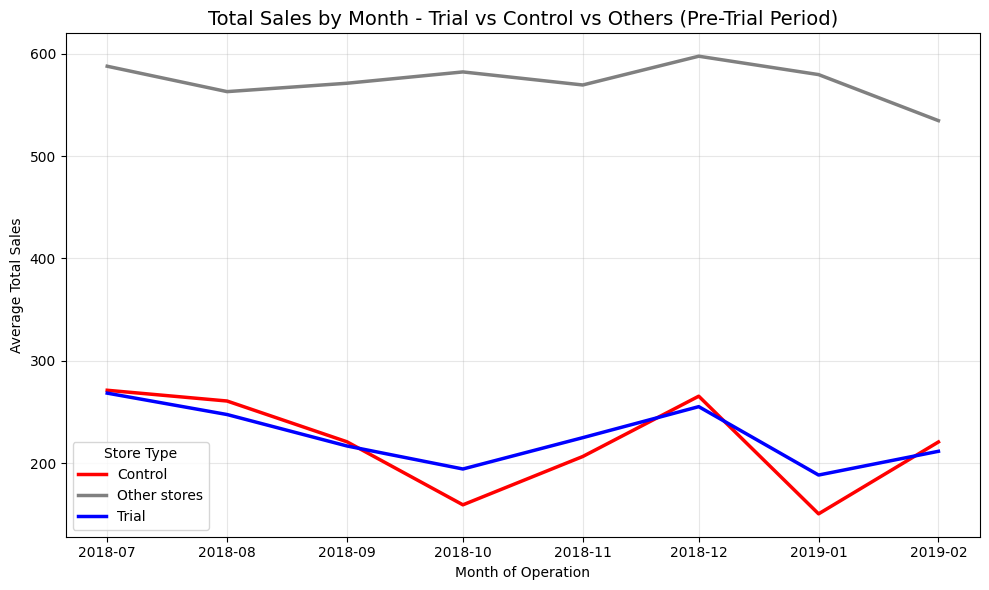

In [21]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=pastSales,
    x='TransactionMonth',
    y='totSales',
    hue='Store_type',
    linewidth=2.5,
    palette={'Trial': 'blue', 'Control': 'red', 'Other stores': 'gray'}
)

plt.title('Total Sales by Month - Trial vs Control vs Others (Pre-Trial Period)', fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Average Total Sales')
plt.legend(title='Store Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#Cleaner Version with Both Sales and Customers Side-by-Side

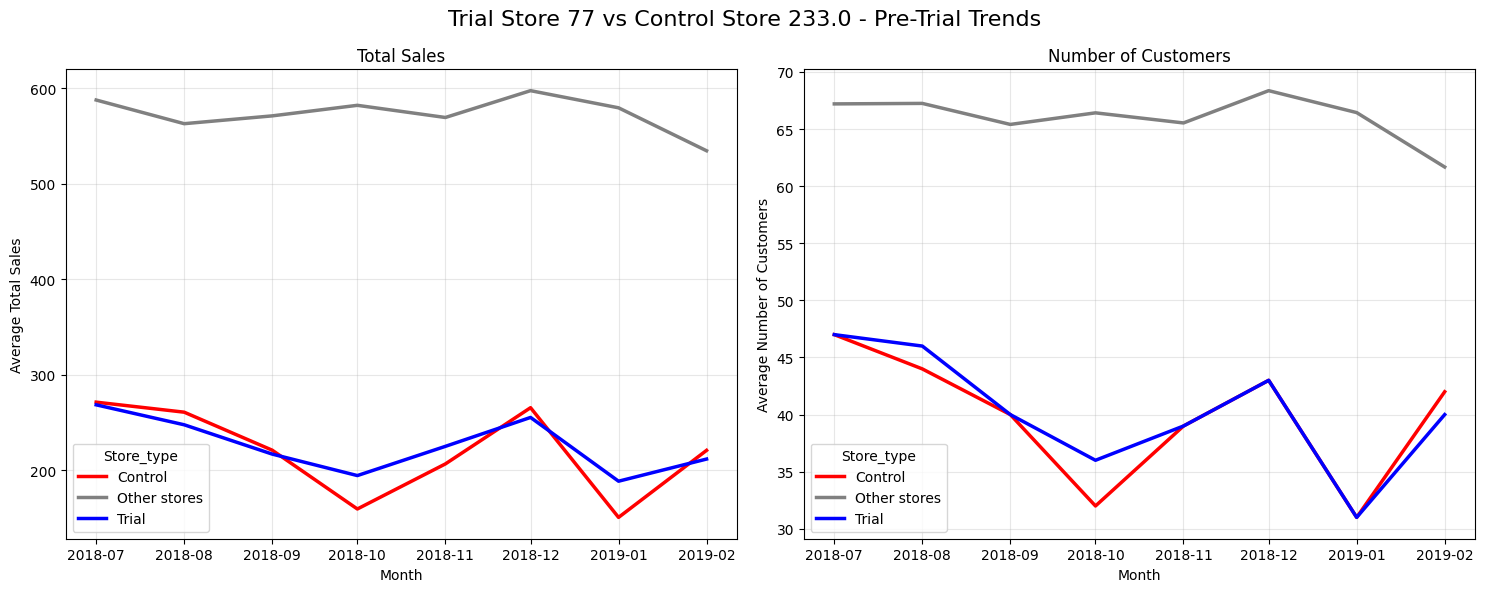

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# === Total Sales ===
sns.lineplot(data=pastSales, x='TransactionMonth', y='totSales', hue='Store_type', 
             linewidth=2.5, ax=axes[0], palette={'Trial': 'blue', 'Control': 'red', 'Other stores': 'gray'})
axes[0].set_title('Total Sales')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Total Sales')
axes[0].grid(True, alpha=0.3)

# === Number of Customers ===
pastCustomers = (
    measureOverTimeSales[measureOverTimeSales['YEARMONTH'] < 201903]
    .groupby(['YEARMONTH', 'Store_type'], as_index=False)['nCustomers']
    .mean()
)
pastCustomers['TransactionMonth'] = pd.to_datetime(
    pastCustomers['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastCustomers['YEARMONTH'].astype(str).str[4:6] + '-01'
)

sns.lineplot(data=pastCustomers, x='TransactionMonth', y='nCustomers', hue='Store_type', 
             linewidth=2.5, ax=axes[1], palette={'Trial': 'blue', 'Control': 'red', 'Other stores': 'gray'})
axes[1].set_title('Number of Customers')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Number of Customers')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Trial Store {trial_store} vs Control Store {control_store} - Pre-Trial Trends', fontsize=16)
plt.tight_layout()
plt.show()

# Scaling Control Store Sales

In [23]:
# Calculate total pre-trial sales (before Feb 2019)
trial_pre_sales = preTrialMeasures[
    (preTrialMeasures['STORE_NBR'] == trial_store) & 
    (preTrialMeasures['YEARMONTH'] < 201902)
]['totSales'].sum()

control_pre_sales = preTrialMeasures[
    (preTrialMeasures['STORE_NBR'] == control_store) & 
    (preTrialMeasures['YEARMONTH'] < 201902)
]['totSales'].sum()

scalingFactorForControlSales = trial_pre_sales / control_pre_sales

print(f"Trial Store: {trial_store} | Control Store: {control_store}")
print(f"Pre-trial Total Sales - Trial Store : {trial_pre_sales:,.2f}")
print(f"Pre-trial Total Sales - Control Store: {control_pre_sales:,.2f}")
print(f"Scaling Factor for Control Store = {scalingFactorForControlSales:.4f}")

Trial Store: 77 | Control Store: 233.0
Pre-trial Total Sales - Trial Store : 1,595.50
Pre-trial Total Sales - Control Store: 1,534.50
Scaling Factor for Control Store = 1.0398


### Apply the scaling factor

In [24]:
# Make a copy of the full measureOverTime data
measureOverTimeSales = measureOverTime.copy()

# Filter only the control store and create scaled sales
scaledControlSales = measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == control_store].copy()

# Apply the scaling factor
scaledControlSales['controlSales'] = scaledControlSales['totSales'] * scalingFactorForControlSales

# Show a sample of the scaled data
print(f"Scaling Factor Applied: {scalingFactorForControlSales:.4f}")
print("\nSample of Scaled Control Sales:")
print(scaledControlSales[['STORE_NBR', 'YEARMONTH', 'totSales', 'controlSales']].head(10))

Scaling Factor Applied: 1.0398

Sample of Scaled Control Sales:
      STORE_NBR  YEARMONTH  totSales  controlSales
2695        233     201807     271.2    281.980841
2696        233     201808     260.7    271.063441
2697        233     201809     220.9    229.681297
2698        233     201810     159.3    165.632551
2699        233     201811     206.5    214.708863
2700        233     201812     265.4    275.950277
2701        233     201901     150.5    156.482731
2702        233     201902     220.7    229.473346
2703        233     201903     180.6    187.779277
2704        233     201904     144.2    149.932291


# Percentage Difference

In [25]:
# Merge Trial sales with Scaled Control sales
percentageDiff = pd.merge(
    measureOverTime[measureOverTime['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]\
        .rename(columns={'totSales': 'trialSales'}),
    
    scaledControlSales[['YEARMONTH', 'controlSales']],
    
    on='YEARMONTH',
    how='inner'
)

# Calculate percentage difference
percentageDiff['percentageDiff'] = (
    (percentageDiff['trialSales'] - percentageDiff['controlSales']) / 
    percentageDiff['controlSales']
) * 100

print("Percentage Difference (Trial vs Scaled Control):")
print(percentageDiff[['YEARMONTH', 'trialSales', 'controlSales', 'percentageDiff']].round(2))

Percentage Difference (Trial vs Scaled Control):
    YEARMONTH  trialSales  controlSales  percentageDiff
0      201807       268.4        281.98           -4.82
1      201808       247.5        271.06           -8.69
2      201809       216.8        229.68           -5.61
3      201810       194.3        165.63           17.31
4      201811       224.9        214.71            4.75
5      201812       255.2        275.95           -7.52
6      201901       188.4        156.48           20.40
7      201902       211.6        229.47           -7.79
8      201903       255.1        187.78           35.85
9      201904       258.1        149.93           72.14
10     201905       272.3        324.51          -16.09
11     201906       246.6        204.83           20.39


# Standard Deviation for Pre-Trial Period

In [26]:
stdDev = percentageDiff[percentageDiff['YEARMONTH'] < 201902]['percentageDiff'].std()

degreesOfFreedom = 7  # 8 months pre-trial - 1

print(f"\nPre-trial Standard Deviation: {stdDev:.4f}")
print(f"Degrees of Freedom: {degreesOfFreedom}")


Pre-trial Standard Deviation: 12.1734
Degrees of Freedom: 7


### CALCULATE T-VALUES FOR TRIAL MONTHS

In [27]:
# Trial period: Feb 2019 to Apr 2019 → YEARMONTH 201902, 201903, 201904
trial_period = [201902, 201903, 201904]

percentageDiff['tValue'] = (percentageDiff['percentageDiff'] - 0) / stdDev

# Convert YEARMONTH to TransactionMonth for readability
percentageDiff['TransactionMonth'] = pd.to_datetime(
    percentageDiff['YEARMONTH'].astype(str).str[:4] + '-' + 
    percentageDiff['YEARMONTH'].astype(str).str[4:6] + '-01'
)

# Show results for trial period
result = percentageDiff[percentageDiff['YEARMONTH'].isin(trial_period)].copy()

print("\n" + "="*60)
print("T-TEST RESULTS DURING TRIAL PERIOD")
print("="*60)
print(result[['TransactionMonth', 'percentageDiff', 'tValue']].round(4))


T-TEST RESULTS DURING TRIAL PERIOD
  TransactionMonth  percentageDiff  tValue
7       2019-02-01         -7.7889 -0.6398
8       2019-03-01         35.8510  2.9450
9       2019-04-01         72.1444  5.9264


### STATISTICAL SIGNIFICANCE (95th Percentile)

In [28]:
# Critical t-value for 95% confidence (one-tailed test, since we expect uplift)
t_critical = stats.t.ppf(0.95, df=degreesOfFreedom)

print(f"\nCritical t-value (95% confidence, df={degreesOfFreedom}): {t_critical:.4f}")

result['Significant'] = result['tValue'] > t_critical

print("\nFinal Assessment:")
print(result[['TransactionMonth', 'percentageDiff', 'tValue', 'Significant']])


Critical t-value (95% confidence, df=7): 1.8946

Final Assessment:
  TransactionMonth  percentageDiff    tValue  Significant
7       2019-02-01       -7.788855 -0.639826        False
8       2019-03-01       35.850987  2.945026         True
9       2019-04-01       72.144372  5.926392         True


### CREATE 95% AND 5% CONFIDENCE BANDS

In [29]:

measureOverTimeSales = measureOverTime.copy()


# Create Store_type
measureOverTimeSales['Store_type'] = np.where(
    measureOverTimeSales['STORE_NBR'] == trial_store, 'Trial',
    np.where(measureOverTimeSales['STORE_NBR'] == control_store, 'Control', 'Other')
)

# Filter only Trial and Control stores
pastSales = measureOverTimeSales[measureOverTimeSales['Store_type'].isin(['Trial', 'Control'])].copy()

# Create TransactionMonth
pastSales['TransactionMonth'] = pd.to_datetime(
    pastSales['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastSales['YEARMONTH'].astype(str).str[4:6] + '-01'
)



# Control store base data
control_data = pastSales[pastSales['Store_type'] == 'Control'].copy()

# 95th percentile line (Upper bound)
pastSales_Controls95 = control_data.copy()
pastSales_Controls95['totSales'] = pastSales_Controls95['totSales'] * (1 + stdDev * 2)
pastSales_Controls95['Store_type'] = 'Control 95th % confidence interval'

# 5th percentile line (Lower bound)
pastSales_Controls5 = control_data.copy()
pastSales_Controls5['totSales'] = pastSales_Controls5['totSales'] * (1 - stdDev * 2)
pastSales_Controls5['Store_type'] = 'Control 5th % confidence interval'

# Combine everything
trialAssessment = pd.concat([pastSales, pastSales_Controls95, pastSales_Controls5], ignore_index=True)



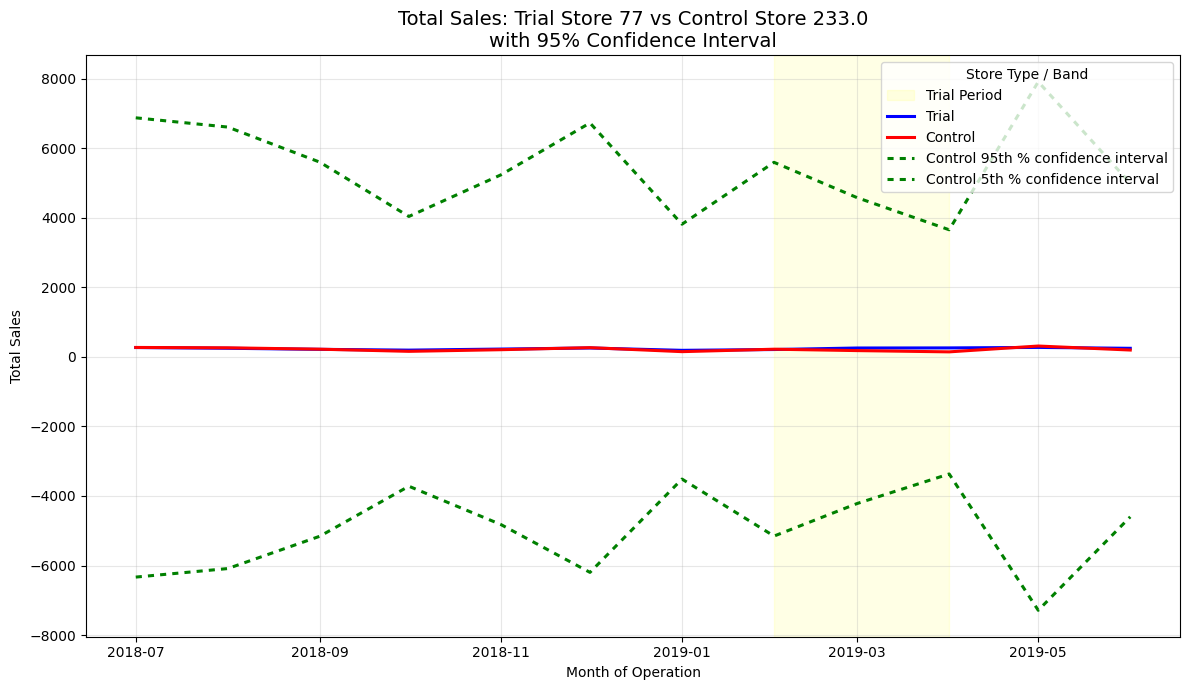

In [30]:
# ====================== PLOT ======================

plt.figure(figsize=(12, 7))

# Plot the confidence interval rectangle for trial period (Feb-Apr 2019)
trial_rect = trialAssessment[(trialAssessment['YEARMONTH'] > 201901) & 
                             (trialAssessment['YEARMONTH'] < 201905)]

if not trial_rect.empty:
    xmin = trial_rect['TransactionMonth'].min()
    xmax = trial_rect['TransactionMonth'].max()
    plt.axvspan(xmin, xmax, ymin=0, ymax=1, alpha=0.1, color='yellow', label='Trial Period')

# Plot all lines
sns.lineplot(
    data=trialAssessment,
    x='TransactionMonth',
    y='totSales',
    hue='Store_type',
    linewidth=2.2,
    palette={
        'Trial': 'blue',
        'Control': 'red',
        'Control 95th % confidence interval': 'green',
        'Control 5th % confidence interval': 'green'
    },
    style='Store_type',
    dashes={
        'Trial': '',
        'Control': '',
        'Control 95th % confidence interval': (2, 2), 
            'Control 5th % confidence interval': (2, 2)}
)

plt.title(f'Total Sales: Trial Store {trial_store} vs Control Store {control_store}\n'
          f'with 95% Confidence Interval', fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.legend(title='Store Type / Band')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### SCALING FACTOR FOR CUSTOMERS 

In [31]:
# Calculate total pre-trial customers (before Feb 2019)
trial_pre_cust = preTrialMeasures[
    (preTrialMeasures['STORE_NBR'] == trial_store) & 
    (preTrialMeasures['YEARMONTH'] < 201902)
]['nCustomers'].sum()

control_pre_cust = preTrialMeasures[
    (preTrialMeasures['STORE_NBR'] == control_store) & 
    (preTrialMeasures['YEARMONTH'] < 201902)
]['nCustomers'].sum()

scalingFactorForControlCust = trial_pre_cust / control_pre_cust

print(f"Scaling Factor for Customers = {scalingFactorForControlCust:.4f}")

Scaling Factor for Customers = 1.0217


### APPLY SCALING & CALCULATE % DIFFERENCE 

In [32]:


measureOverTimeCusts = measureOverTime.copy()

scaledControlCustomers = measureOverTimeCusts[measureOverTimeCusts['STORE_NBR'] == control_store].copy()
scaledControlCustomers['controlCustomers'] = scaledControlCustomers['nCustomers'] * scalingFactorForControlCust

# Merge with Trial store customer counts
percentageDiff_cust = pd.merge(
    measureOverTimeCusts[measureOverTimeCusts['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']]\
        .rename(columns={'nCustomers': 'trialCustomers'}),
    
    scaledControlCustomers[['YEARMONTH', 'controlCustomers']],
    on='YEARMONTH',
    how='inner'
)

percentageDiff_cust['percentageDiff'] = (
    (percentageDiff_cust['trialCustomers'] - percentageDiff_cust['controlCustomers']) / 
    percentageDiff_cust['controlCustomers']
) * 100

# Calculate stdDev from pre-trial period
stdDev_cust = percentageDiff_cust[percentageDiff_cust['YEARMONTH'] < 201902]['percentageDiff'].std()
print(f"Pre-trial Customer % Difference StdDev = {stdDev_cust:.4f}")

Pre-trial Customer % Difference StdDev = 4.6494


### VISUAL ASSESSMENT PLOT (with Confidence Bands)

In [33]:
# Prepare data for plotting
pastCustomers = measureOverTimeCusts.copy()
pastCustomers['Store_type'] = np.where(
    pastCustomers['STORE_NBR'] == trial_store, 'Trial',
    np.where(pastCustomers['STORE_NBR'] == control_store, 'Control', 'Other')
)

pastCustomers = pastCustomers[pastCustomers['Store_type'].isin(['Trial', 'Control'])].copy()
pastCustomers['TransactionMonth'] = pd.to_datetime(
    pastCustomers['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastCustomers['YEARMONTH'].astype(str).str[4:6] + '-01'
)

# Create confidence bands
control_cust = pastCustomers[pastCustomers['Store_type'] == 'Control'].copy()

cust_95 = control_cust.copy()
cust_95['nCusts'] = cust_95['nCustomers'] * (1 + stdDev_cust * 2)
cust_95['Store_type'] = 'Control 95th % confidence interval'

cust_5 = control_cust.copy()
cust_5['nCusts'] = cust_5['nCustomers'] * (1 - stdDev_cust * 2)
cust_5['Store_type'] = 'Control 5th % confidence interval'

trialAssessment_cust = pd.concat([pastCustomers.assign(nCusts=pastCustomers['nCustomers']), 
                                  cust_95, cust_5], ignore_index=True)

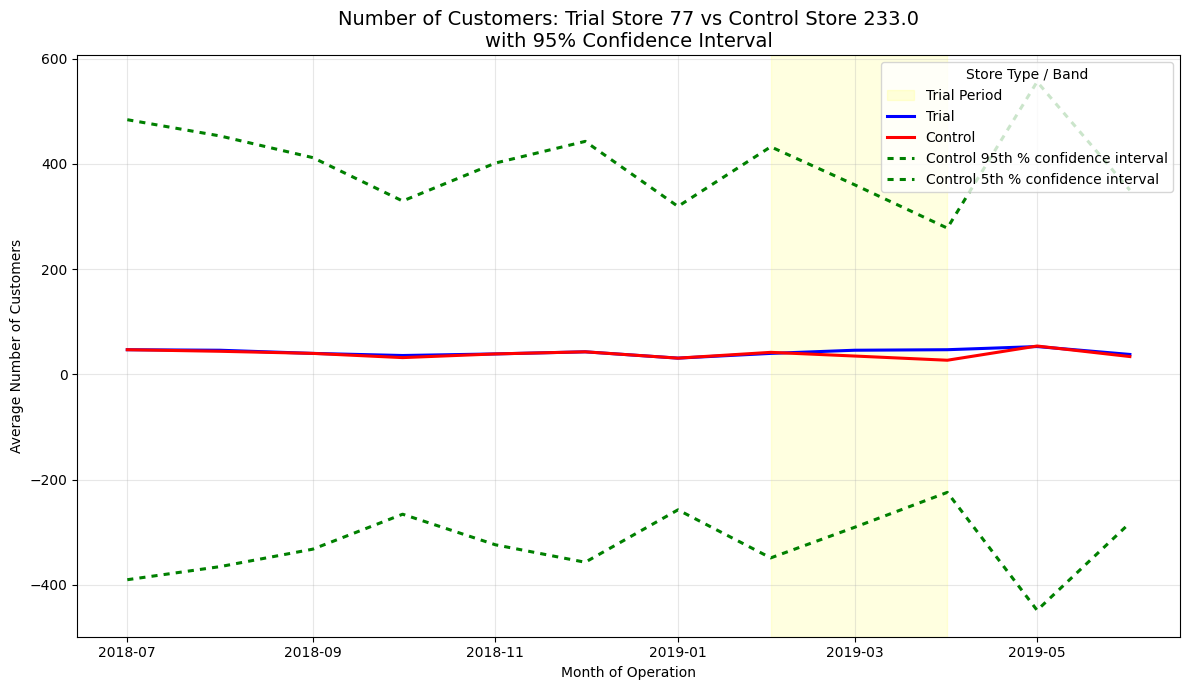

In [34]:
plt.figure(figsize=(12, 7))

# Highlight trial period (Feb-Apr 2019)
plt.axvspan(pd.to_datetime('2019-02-01'), pd.to_datetime('2019-04-01'), 
            alpha=0.12, color='yellow', label='Trial Period')

sns.lineplot(
    data=trialAssessment_cust,
    x='TransactionMonth',
    y='nCusts',
    hue='Store_type',
    linewidth=2.2,
    palette={
        'Trial': 'blue',
        'Control': 'red',
        'Control 95th % confidence interval': 'green',
        'Control 5th % confidence interval': 'green'
    },
    style='Store_type',
    dashes={
        'Trial': '',
        'Control': '',
        'Control 95th % confidence interval': (2,2), 
            'Control 5th % confidence interval': (2,2)}
)

plt.title(f'Number of Customers: Trial Store {trial_store} vs Control Store {control_store}\n'
          f'with 95% Confidence Interval', fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Average Number of Customers')
plt.legend(title='Store Type / Band')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### TRIAL STORE 86 ANALYSIS

In [35]:


trial_store = 86


print(f"ANALYSIS FOR TRIAL STORE {trial_store}")


# ====================== 1. CALCULATE CORRELATIONS ======================
corr_nSales = calculate_correlation(preTrialMeasures, 'totSales', trial_store)
corr_nCustomers = calculate_correlation(preTrialMeasures, 'nCustomers', trial_store)

# ====================== 2. CALCULATE MAGNITUDE DISTANCES ======================
magnitude_nSales = calculate_magnitude_distance(preTrialMeasures, 'totSales', trial_store)
magnitude_nCustomers = calculate_magnitude_distance(preTrialMeasures, 'nCustomers', trial_store)

# ====================== 3. COMBINE SCORES ======================
corr_weight = 0.5

score_nSales = pd.merge(corr_nSales, magnitude_nSales, on=['Store1', 'Store2'])
score_nSales['scoreNSales'] = corr_weight * score_nSales['corr_measure'] + \
                              (1 - corr_weight) * score_nSales['mag_measure']

score_nCustomers = pd.merge(corr_nCustomers, magnitude_nCustomers, on=['Store1', 'Store2'])
score_nCustomers['scoreNCust'] = corr_weight * score_nCustomers['corr_measure'] + \
                                 (1 - corr_weight) * score_nCustomers['mag_measure']

# Final combined score
score_Control = pd.merge(score_nSales[['Store1', 'Store2', 'scoreNSales']], 
                         score_nCustomers[['Store1', 'Store2', 'scoreNCust']], 
                         on=['Store1', 'Store2'])

score_Control['finalControlScore'] = 0.5 * score_Control['scoreNSales'] + \
                                     0.5 * score_Control['scoreNCust']

# ====================== 4. SELECT BEST CONTROL STORE ======================
control_store = score_Control[score_Control['Store2'] != trial_store] \
                    .sort_values('finalControlScore', ascending=False) \
                    .iloc[0]['Store2']

print(f"Best Control Store for Trial Store {trial_store} is: **{control_store}**")

ANALYSIS FOR TRIAL STORE 86
Best Control Store for Trial Store 86 is: **155.0**


In [36]:
def plot_driver_comparison(trial_store, control_store, metric='totSales', title=None):
    """Plot Trial vs Control for a given metric with pre-trial data"""
    df = measureOverTime.copy()
    
    df['Store_type'] = np.where(df['STORE_NBR'] == trial_store, 'Trial',
                      np.where(df['STORE_NBR'] == control_store, 'Control', 'Other stores'))
    
    plot_data = df[df['Store_type'].isin(['Trial', 'Control'])].copy()
    plot_data['TransactionMonth'] = pd.to_datetime(
        plot_data['YEARMONTH'].astype(str).str[:4] + '-' + 
        plot_data['YEARMONTH'].astype(str).str[4:6] + '-01'
    )
    
    avg_data = plot_data.groupby(['TransactionMonth', 'Store_type'], as_index=False)[metric].mean()
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=avg_data, x='TransactionMonth', y=metric, hue='Store_type', 
                 linewidth=2.5, palette={'Trial': 'blue', 'Control': 'red'})
    
    plt.title(title or f'{metric} Trend - Trial {trial_store} vs Control {control_store}')
    plt.xlabel('Month of Operation')
    plt.ylabel(metric.replace('totSales', 'Total Sales').replace('nCustomers', 'Number of Customers'))
    plt.grid(True, alpha=0.3)
    plt.legend(title='Store Type')
    plt.tight_layout()
    plt.show()
    
    

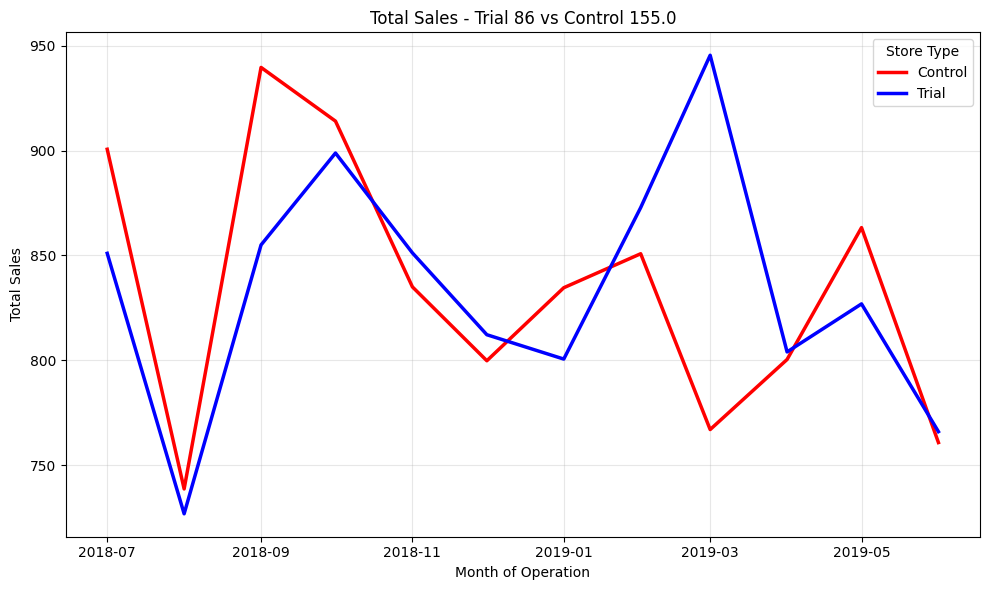

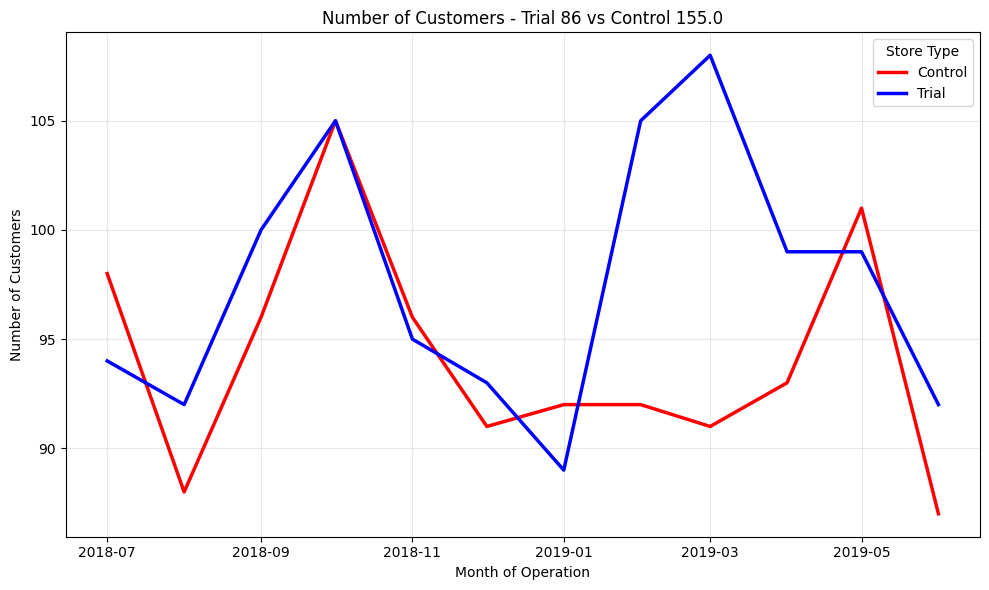

In [37]:


# ====================== 5. VISUAL CHECK - TOTAL SALES ======================
plot_driver_comparison(trial_store, control_store, metric='totSales', 
                       title=f'Total Sales - Trial {trial_store} vs Control {control_store}')

# ====================== 6. VISUAL CHECK - NUMBER OF CUSTOMERS ======================
plot_driver_comparison(trial_store, control_store, metric='nCustomers', 
                       title=f'Number of Customers - Trial {trial_store} vs Control {control_store}')

#### TRIAL IMPACT ASSESSMENT - SALES

In [38]:


trial_store = 86          # Change to 88 when needed
control_store = 155       # From earlier result for trial store 86

print(f"Assessing Trial Impact for Trial Store {trial_store} (Control: {control_store})")

# ====================== 1. SCALING FACTOR ======================
pre_trial_sales = preTrialMeasures[preTrialMeasures['YEARMONTH'] < 201902]

scalingFactorForControlSales = (
    pre_trial_sales[pre_trial_sales['STORE_NBR'] == trial_store]['totSales'].sum() /
    pre_trial_sales[pre_trial_sales['STORE_NBR'] == control_store]['totSales'].sum()
)

print(f"Scaling Factor for Control Sales = {scalingFactorForControlSales:.4f}")

# ====================== 2. APPLY SCALING ======================
measureOverTimeSales = measureOverTime.copy()

scaledControlSales = measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == control_store].copy()
scaledControlSales['controlSales'] = scaledControlSales['totSales'] * scalingFactorForControlSales

# ====================== 3. PERCENTAGE DIFFERENCE ======================
percentageDiff = pd.merge(
    measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]\
        .rename(columns={'totSales': 'trialSales'}),
    
    scaledControlSales[['YEARMONTH', 'controlSales']],
    on='YEARMONTH',
    how='inner'
)

percentageDiff['percentageDiff'] = (
    (percentageDiff['trialSales'] - percentageDiff['controlSales']) / 
    percentageDiff['controlSales']
) * 100

# Pre-trial standard deviation
stdDev = percentageDiff[percentageDiff['YEARMONTH'] < 201902]['percentageDiff'].std()
degreesOfFreedom = 7

print(f"Pre-trial % Difference StdDev = {stdDev:.4f}")



Assessing Trial Impact for Trial Store 86 (Control: 155)
Scaling Factor for Control Sales = 0.9720
Pre-trial % Difference StdDev = 4.0139


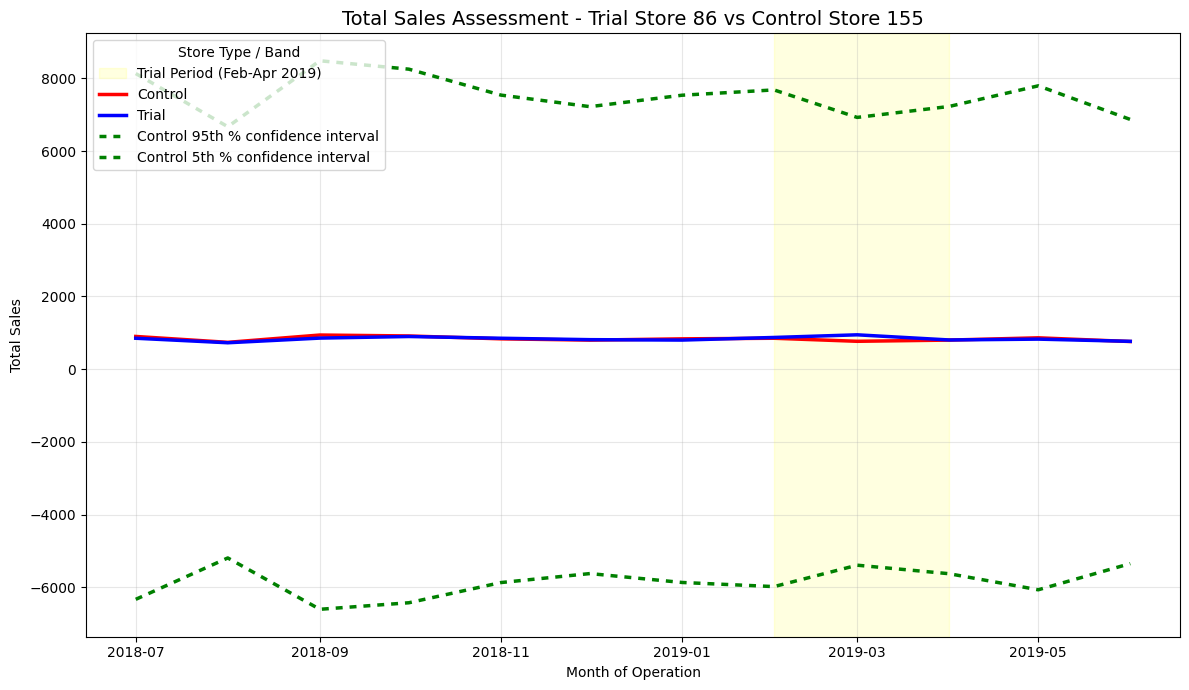

In [39]:
# ====================== 4. PREPARE PAST SALES FOR PLOTTING ======================
pastSales = measureOverTimeSales.copy()

pastSales['Store_type'] = np.where(
    pastSales['STORE_NBR'] == trial_store, 'Trial',
    np.where(pastSales['STORE_NBR'] == control_store, 'Control', 'Other')
)

pastSales = pastSales[pastSales['Store_type'].isin(['Trial', 'Control'])].copy()

pastSales['TransactionMonth'] = pd.to_datetime(
    pastSales['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastSales['YEARMONTH'].astype(str).str[4:6] + '-01'
)

# Average sales per month and store type
pastSales = pastSales.groupby(['YEARMONTH', 'TransactionMonth', 'Store_type'], as_index=False)['totSales'].mean()

# ====================== 5. CREATE 95% & 5% CONFIDENCE BANDS ======================
control_base = pastSales[pastSales['Store_type'] == 'Control'].copy()

# Note: We scale the dollar sales using the percentage stdDev
pastSales_Controls95 = control_base.copy()
pastSales_Controls95['totSales'] = pastSales_Controls95['totSales'] * (1 + stdDev * 2)
pastSales_Controls95['Store_type'] = 'Control 95th % confidence interval'

pastSales_Controls5 = control_base.copy()
pastSales_Controls5['totSales'] = pastSales_Controls5['totSales'] * (1 - stdDev * 2)
pastSales_Controls5['Store_type'] = 'Control 5th % confidence interval'

# Combine all
trialAssessment = pd.concat([pastSales, pastSales_Controls95, pastSales_Controls5], ignore_index=True)

# ====================== 6. FINAL PLOT ======================
plt.figure(figsize=(12, 7))

# Highlight Trial Period (Feb - Apr 2019)
plt.axvspan(pd.to_datetime('2019-02-01'), pd.to_datetime('2019-04-01'), 
            alpha=0.12, color='yellow', label='Trial Period (Feb-Apr 2019)')

sns.lineplot(
    data=trialAssessment,
    x='TransactionMonth',
    y='totSales',
    hue='Store_type',
    style='Store_type',
    linewidth=2.5,
    palette={
        'Trial': 'blue',
        'Control': 'red',
        'Control 95th % confidence interval': 'green',
        'Control 5th % confidence interval': 'green'
    },
    dashes={'Trial': '',
        'Control': '',
        'Control 95th % confidence interval': (2, 2), 
            'Control 5th % confidence interval': (2, 2)}
)

plt.title(f'Total Sales Assessment - Trial Store {trial_store} vs Control Store {control_store}', 
          fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.legend(title='Store Type / Band')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### CUSTOMER IMPACT ASSESSMENT - TRIAL STORE 86

In [40]:


trial_store = 86
control_store = 155                     # From earlier control store selection

print(f"Assessing Customer Impact for Trial Store {trial_store} (Control: {control_store})")

# ====================== 1. SCALING FACTOR FOR CUSTOMERS ======================
pre_trial = preTrialMeasures[preTrialMeasures['YEARMONTH'] < 201902]

scalingFactorForControlCust = (
    pre_trial[pre_trial['STORE_NBR'] == trial_store]['nCustomers'].sum() /
    pre_trial[pre_trial['STORE_NBR'] == control_store]['nCustomers'].sum()
)

print(f"Scaling Factor for Control Customers = {scalingFactorForControlCust:.4f}")

# ====================== 2. APPLY SCALING ======================
measureOverTimeCusts = measureOverTime.copy()

scaledControlCustomers = measureOverTimeCusts[measureOverTimeCusts['STORE_NBR'] == control_store].copy()
scaledControlCustomers['controlCustomers'] = scaledControlCustomers['nCustomers'] * scalingFactorForControlCust

# Add Store_type
scaledControlCustomers['Store_type'] = np.where(
    scaledControlCustomers['STORE_NBR'] == trial_store, 'Trial',
    np.where(scaledControlCustomers['STORE_NBR'] == control_store, 'Control', 'Other stores')
)

# ====================== 3. PERCENTAGE DIFFERENCE ======================
percentageDiff = pd.merge(
    scaledControlCustomers[['YEARMONTH', 'controlCustomers']],
    measureOverTimeCusts[measureOverTimeCusts['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']],
    on='YEARMONTH',
    how='inner'
)

percentageDiff['percentageDiff'] = abs(percentageDiff['controlCustomers'] - percentageDiff['nCustomers']) / \
                                   percentageDiff['controlCustomers'] * 100

# Pre-trial standard deviation
stdDev = percentageDiff[percentageDiff['YEARMONTH'] < 201902]['percentageDiff'].std()
degreesOfFreedom = 7

print(f"Pre-trial Customer % StdDev = {stdDev:.4f}")



Assessing Customer Impact for Trial Store 86 (Control: 155)
Scaling Factor for Control Customers = 1.0030
Pre-trial Customer % StdDev = 1.6023


In [41]:
# ====================== 4. PREPARE DATA FOR PLOTTING ======================
pastCustomers = measureOverTimeCusts.copy()

pastCustomers['Store_type'] = np.where(
    pastCustomers['STORE_NBR'] == trial_store, 'Trial',
    np.where(pastCustomers['STORE_NBR'] == control_store, 'Control', 'Other stores')
)

pastCustomers = pastCustomers[pastCustomers['Store_type'].isin(['Trial', 'Control'])].copy()

pastCustomers['TransactionMonth'] = pd.to_datetime(
    pastCustomers['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastCustomers['YEARMONTH'].astype(str).str[4:6] + '-01'
)

# Average number of customers per month
pastCustomers = pastCustomers.groupby(['YEARMONTH', 'TransactionMonth', 'Store_type'], 
                                      as_index=False)['nCustomers'].mean()
pastCustomers = pastCustomers.rename(columns={'nCustomers': 'nCusts'})

# ====================== 5. CREATE CONFIDENCE BANDS ======================
control_base = pastCustomers[pastCustomers['Store_type'] == 'Control'].copy()

pastCustomers_Controls95 = control_base.copy()
pastCustomers_Controls95['nCusts'] = pastCustomers_Controls95['nCusts'] * (1 + stdDev * 2)
pastCustomers_Controls95['Store_type'] = 'Control 95th % confidence interval'

pastCustomers_Controls5 = control_base.copy()
pastCustomers_Controls5['nCusts'] = pastCustomers_Controls5['nCusts'] * (1 - stdDev * 2)
pastCustomers_Controls5['Store_type'] = 'Control 5th % confidence interval'

# Combine all layers
trialAssessment = pd.concat([pastCustomers, pastCustomers_Controls95, pastCustomers_Controls5], 
                            ignore_index=True)



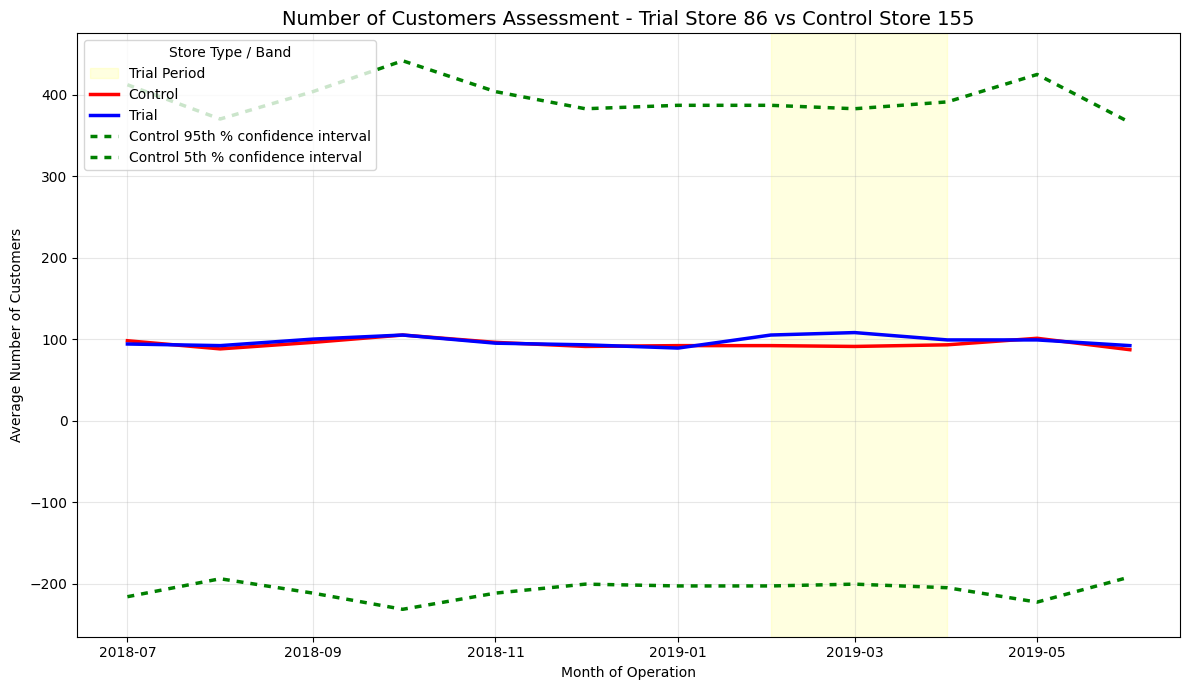

In [42]:
# ====================== 6. FINAL PLOT ======================
plt.figure(figsize=(12, 7))

# Highlight Trial Period (Feb–Apr 2019)
plt.axvspan(pd.to_datetime('2019-02-01'), pd.to_datetime('2019-04-01'), 
            alpha=0.12, color='yellow', label='Trial Period')

sns.lineplot(
    data=trialAssessment,
    x='TransactionMonth',
    y='nCusts',
    hue='Store_type',
    style='Store_type',
    linewidth=2.5,
    palette={
        'Trial': 'blue',
        'Control': 'red',
        'Control 95th % confidence interval': 'green',
        'Control 5th % confidence interval': 'green'
    },
    dashes={'Trial': '',
        'Control': '',
        'Control 95th % confidence interval': (2, 2), 
            'Control 5th % confidence interval': (2, 2)}
)

plt.title(f'Number of Customers Assessment - Trial Store {trial_store} vs Control Store {control_store}', 
          fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Average Number of Customers')
plt.legend(title='Store Type / Band')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### TRIAL STORE 88 ANALYSIS

In [43]:
trial_store = 88


print(f"ANALYSIS FOR TRIAL STORE {trial_store}")


# ====================== 1. CALCULATE CORRELATIONS ======================
corr_nSales = calculate_correlation(preTrialMeasures, 'totSales', trial_store)
corr_nCustomers = calculate_correlation(preTrialMeasures, 'nCustomers', trial_store)

# ====================== 2. CALCULATE MAGNITUDE DISTANCES ======================
magnitude_nSales = calculate_magnitude_distance(preTrialMeasures, 'totSales', trial_store)
magnitude_nCustomers = calculate_magnitude_distance(preTrialMeasures, 'nCustomers', trial_store)

# ====================== 3. COMBINE SCORES ======================
corr_weight = 0.5

score_nSales = pd.merge(corr_nSales, magnitude_nSales, on=['Store1', 'Store2'])
score_nSales['scoreNSales'] = corr_weight * score_nSales['corr_measure'] + \
                              (1 - corr_weight) * score_nSales['mag_measure']

score_nCustomers = pd.merge(corr_nCustomers, magnitude_nCustomers, on=['Store1', 'Store2'])
score_nCustomers['scoreNCust'] = corr_weight * score_nCustomers['corr_measure'] + \
                                 (1 - corr_weight) * score_nCustomers['mag_measure']

# Final combined score
score_Control = pd.merge(score_nSales[['Store1', 'Store2', 'scoreNSales']], 
                         score_nCustomers[['Store1', 'Store2', 'scoreNCust']], 
                         on=['Store1', 'Store2'])

score_Control['finalControlScore'] = 0.5 * score_Control['scoreNSales'] + \
                                     0.5 * score_Control['scoreNCust']

# ====================== 4. SELECT BEST CONTROL STORE ======================
control_store = score_Control[score_Control['Store2'] != trial_store] \
                    .sort_values('finalControlScore', ascending=False) \
                    .iloc[0]['Store2']

print(f"Best Control Store for Trial Store {trial_store} is: **{control_store}**")

ANALYSIS FOR TRIAL STORE 88
Best Control Store for Trial Store 88 is: **237.0**


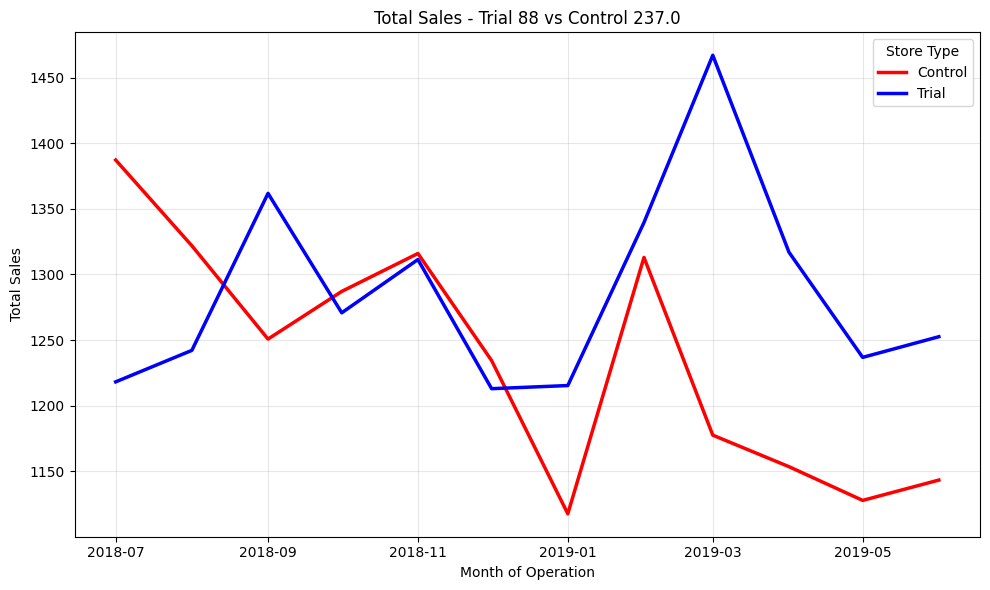

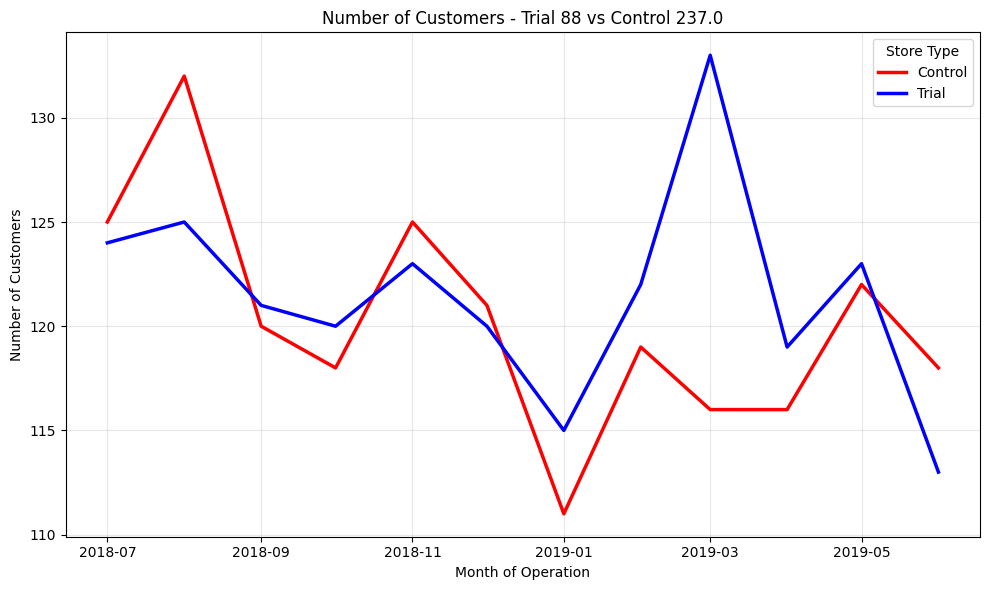

In [44]:
def plot_driver_comparison(trial_store, control_store, metric='totSales', title=None):
    """Plot Trial vs Control for a given metric with pre-trial data"""
    df = measureOverTime.copy()
    
    df['Store_type'] = np.where(df['STORE_NBR'] == trial_store, 'Trial',
                      np.where(df['STORE_NBR'] == control_store, 'Control', 'Other stores'))
    
    plot_data = df[df['Store_type'].isin(['Trial', 'Control'])].copy()
    plot_data['TransactionMonth'] = pd.to_datetime(
        plot_data['YEARMONTH'].astype(str).str[:4] + '-' + 
        plot_data['YEARMONTH'].astype(str).str[4:6] + '-01'
    )
    
    avg_data = plot_data.groupby(['TransactionMonth', 'Store_type'], as_index=False)[metric].mean()
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=avg_data, x='TransactionMonth', y=metric, hue='Store_type', 
                 linewidth=2.5, palette={'Trial': 'blue', 'Control': 'red'})
    
    plt.title(title or f'{metric} Trend - Trial {trial_store} vs Control {control_store}')
    plt.xlabel('Month of Operation')
    plt.ylabel(metric.replace('totSales', 'Total Sales').replace('nCustomers', 'Number of Customers'))
    plt.grid(True, alpha=0.3)
    plt.legend(title='Store Type')
    plt.tight_layout()
    plt.show()
    
    # ====================== 5. VISUAL CHECK - TOTAL SALES ======================
plot_driver_comparison(trial_store, control_store, metric='totSales', 
                       title=f'Total Sales - Trial {trial_store} vs Control {control_store}')

# ====================== 6. VISUAL CHECK - NUMBER OF CUSTOMERS ======================
plot_driver_comparison(trial_store, control_store, metric='nCustomers', 
                       title=f'Number of Customers - Trial {trial_store} vs Control {control_store}')

#### TRIAL IMPACT ASSESSMENT - SALES

In [45]:
trial_store = 88          # Change to 88 when needed
control_store = 237       # From earlier result for trial store 86

print(f"Assessing Trial Impact for Trial Store {trial_store} (Control: {control_store})")

# ====================== 1. SCALING FACTOR ======================
pre_trial_sales = preTrialMeasures[preTrialMeasures['YEARMONTH'] < 201902]

scalingFactorForControlSales = (
    pre_trial_sales[pre_trial_sales['STORE_NBR'] == trial_store]['totSales'].sum() /
    pre_trial_sales[pre_trial_sales['STORE_NBR'] == control_store]['totSales'].sum()
)

print(f"Scaling Factor for Control Sales = {scalingFactorForControlSales:.4f}")

# ====================== 2. APPLY SCALING ======================
measureOverTimeSales = measureOverTime.copy()

scaledControlSales = measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == control_store].copy()
scaledControlSales['controlSales'] = scaledControlSales['totSales'] * scalingFactorForControlSales

# ====================== 3. PERCENTAGE DIFFERENCE ======================
percentageDiff = pd.merge(
    measureOverTimeSales[measureOverTimeSales['STORE_NBR'] == trial_store][['YEARMONTH', 'totSales']]\
        .rename(columns={'totSales': 'trialSales'}),
    
    scaledControlSales[['YEARMONTH', 'controlSales']],
    on='YEARMONTH',
    how='inner'
)

percentageDiff['percentageDiff'] = (
    (percentageDiff['trialSales'] - percentageDiff['controlSales']) / 
    percentageDiff['controlSales']
) * 100

# Pre-trial standard deviation
stdDev = percentageDiff[percentageDiff['YEARMONTH'] < 201902]['percentageDiff'].std()
degreesOfFreedom = 7

print(f"Pre-trial % Difference StdDev = {stdDev:.4f}")

Assessing Trial Impact for Trial Store 88 (Control: 237)
Scaling Factor for Control Sales = 0.9908
Pre-trial % Difference StdDev = 7.6251


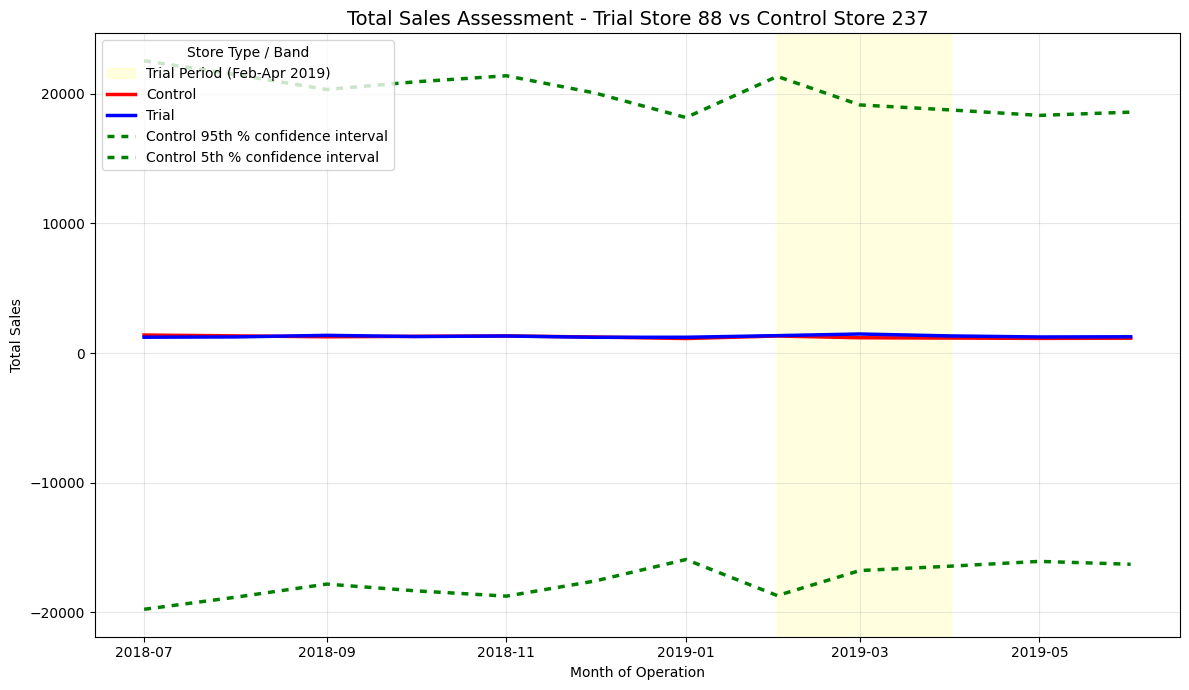

In [46]:
# ====================== 4. PREPARE PAST SALES FOR PLOTTING ======================
pastSales = measureOverTimeSales.copy()

pastSales['Store_type'] = np.where(
    pastSales['STORE_NBR'] == trial_store, 'Trial',
    np.where(pastSales['STORE_NBR'] == control_store, 'Control', 'Other')
)

pastSales = pastSales[pastSales['Store_type'].isin(['Trial', 'Control'])].copy()

pastSales['TransactionMonth'] = pd.to_datetime(
    pastSales['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastSales['YEARMONTH'].astype(str).str[4:6] + '-01'
)

# Average sales per month and store type
pastSales = pastSales.groupby(['YEARMONTH', 'TransactionMonth', 'Store_type'], as_index=False)['totSales'].mean()

# ====================== 5. CREATE 95% & 5% CONFIDENCE BANDS ======================
control_base = pastSales[pastSales['Store_type'] == 'Control'].copy()

# Note: We scale the dollar sales using the percentage stdDev
pastSales_Controls95 = control_base.copy()
pastSales_Controls95['totSales'] = pastSales_Controls95['totSales'] * (1 + stdDev * 2)
pastSales_Controls95['Store_type'] = 'Control 95th % confidence interval'

pastSales_Controls5 = control_base.copy()
pastSales_Controls5['totSales'] = pastSales_Controls5['totSales'] * (1 - stdDev * 2)
pastSales_Controls5['Store_type'] = 'Control 5th % confidence interval'

# Combine all
trialAssessment = pd.concat([pastSales, pastSales_Controls95, pastSales_Controls5], ignore_index=True)

# ====================== 6. FINAL PLOT ======================
plt.figure(figsize=(12, 7))

# Highlight Trial Period (Feb - Apr 2019)
plt.axvspan(pd.to_datetime('2019-02-01'), pd.to_datetime('2019-04-01'), 
            alpha=0.12, color='yellow', label='Trial Period (Feb-Apr 2019)')

sns.lineplot(
    data=trialAssessment,
    x='TransactionMonth',
    y='totSales',
    hue='Store_type',
    style='Store_type',
    linewidth=2.5,
    palette={
        'Trial': 'blue',
        'Control': 'red',
        'Control 95th % confidence interval': 'green',
        'Control 5th % confidence interval': 'green'
    },
    dashes={'Trial': '',
        'Control': '',
        'Control 95th % confidence interval': (2, 2), 
            'Control 5th % confidence interval': (2, 2)}
)

plt.title(f'Total Sales Assessment - Trial Store {trial_store} vs Control Store {control_store}', 
          fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Total Sales')
plt.legend(title='Store Type / Band')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### CUSTOMER IMPACT ASSESSMENT - TRIAL STORE 88

In [47]:
trial_store = 88
control_store = 237                     # From earlier control store selection

print(f"Assessing Customer Impact for Trial Store {trial_store} (Control: {control_store})")

# ====================== 1. SCALING FACTOR FOR CUSTOMERS ======================
pre_trial = preTrialMeasures[preTrialMeasures['YEARMONTH'] < 201902]

scalingFactorForControlCust = (
    pre_trial[pre_trial['STORE_NBR'] == trial_store]['nCustomers'].sum() /
    pre_trial[pre_trial['STORE_NBR'] == control_store]['nCustomers'].sum()
)

print(f"Scaling Factor for Control Customers = {scalingFactorForControlCust:.4f}")

# ====================== 2. APPLY SCALING ======================
measureOverTimeCusts = measureOverTime.copy()

scaledControlCustomers = measureOverTimeCusts[measureOverTimeCusts['STORE_NBR'] == control_store].copy()
scaledControlCustomers['controlCustomers'] = scaledControlCustomers['nCustomers'] * scalingFactorForControlCust

# Add Store_type
scaledControlCustomers['Store_type'] = np.where(
    scaledControlCustomers['STORE_NBR'] == trial_store, 'Trial',
    np.where(scaledControlCustomers['STORE_NBR'] == control_store, 'Control', 'Other stores')
)

# ====================== 3. PERCENTAGE DIFFERENCE ======================
percentageDiff = pd.merge(
    scaledControlCustomers[['YEARMONTH', 'controlCustomers']],
    measureOverTimeCusts[measureOverTimeCusts['STORE_NBR'] == trial_store][['YEARMONTH', 'nCustomers']],
    on='YEARMONTH',
    how='inner'
)

percentageDiff['percentageDiff'] = abs(percentageDiff['controlCustomers'] - percentageDiff['nCustomers']) / \
                                   percentageDiff['controlCustomers'] * 100

# Pre-trial standard deviation
stdDev = percentageDiff[percentageDiff['YEARMONTH'] < 201902]['percentageDiff'].std()
degreesOfFreedom = 7

print(f"Pre-trial Customer % StdDev = {stdDev:.4f}")

Assessing Customer Impact for Trial Store 88 (Control: 237)
Scaling Factor for Control Customers = 0.9953
Pre-trial Customer % StdDev = 1.7915


In [48]:
# ====================== 4. PREPARE DATA FOR PLOTTING ======================
pastCustomers = measureOverTimeCusts.copy()

pastCustomers['Store_type'] = np.where(
    pastCustomers['STORE_NBR'] == trial_store, 'Trial',
    np.where(pastCustomers['STORE_NBR'] == control_store, 'Control', 'Other stores')
)

pastCustomers = pastCustomers[pastCustomers['Store_type'].isin(['Trial', 'Control'])].copy()

pastCustomers['TransactionMonth'] = pd.to_datetime(
    pastCustomers['YEARMONTH'].astype(str).str[:4] + '-' + 
    pastCustomers['YEARMONTH'].astype(str).str[4:6] + '-01'
)

# Average number of customers per month
pastCustomers = pastCustomers.groupby(['YEARMONTH', 'TransactionMonth', 'Store_type'], 
                                      as_index=False)['nCustomers'].mean()
pastCustomers = pastCustomers.rename(columns={'nCustomers': 'nCusts'})

# ====================== 5. CREATE CONFIDENCE BANDS ======================
control_base = pastCustomers[pastCustomers['Store_type'] == 'Control'].copy()

pastCustomers_Controls95 = control_base.copy()
pastCustomers_Controls95['nCusts'] = pastCustomers_Controls95['nCusts'] * (1 + stdDev * 2)
pastCustomers_Controls95['Store_type'] = 'Control 95th % confidence interval'

pastCustomers_Controls5 = control_base.copy()
pastCustomers_Controls5['nCusts'] = pastCustomers_Controls5['nCusts'] * (1 - stdDev * 2)
pastCustomers_Controls5['Store_type'] = 'Control 5th % confidence interval'

# Combine all layers
trialAssessment = pd.concat([pastCustomers, pastCustomers_Controls95, pastCustomers_Controls5], 
                            ignore_index=True)



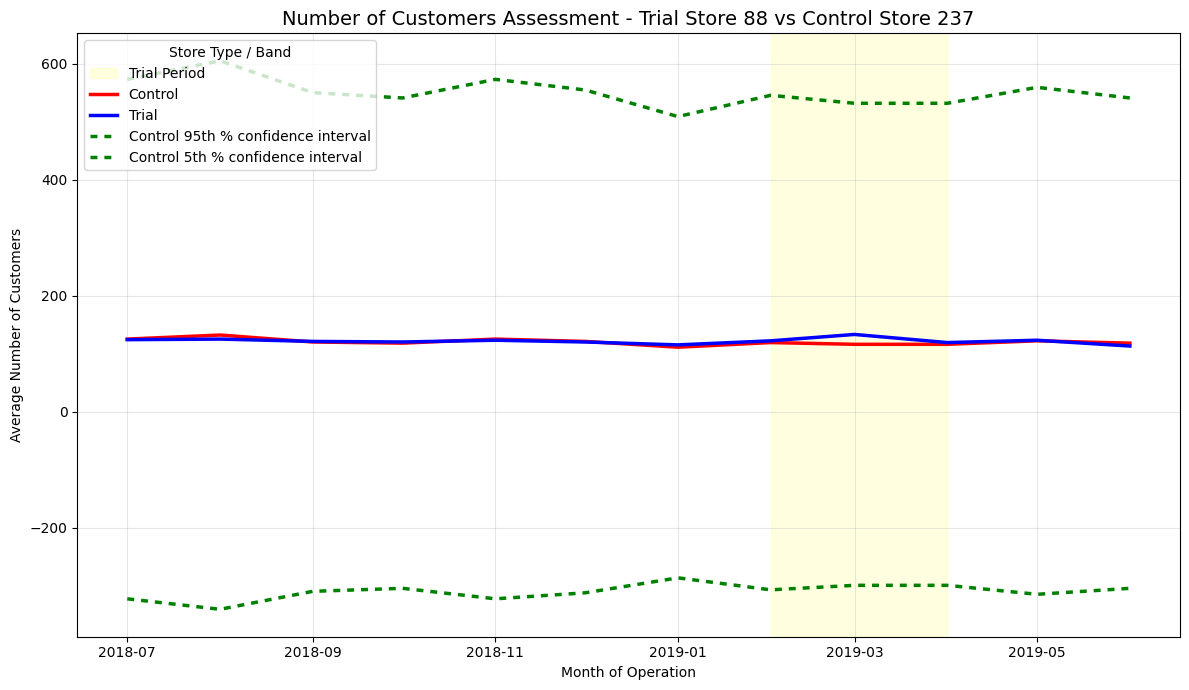

In [49]:
# ====================== 6. FINAL PLOT ======================
plt.figure(figsize=(12, 7))

# Highlight Trial Period (Feb–Apr 2019)
plt.axvspan(pd.to_datetime('2019-02-01'), pd.to_datetime('2019-04-01'), 
            alpha=0.12, color='yellow', label='Trial Period')

sns.lineplot(
    data=trialAssessment,
    x='TransactionMonth',
    y='nCusts',
    hue='Store_type',
    style='Store_type',
    linewidth=2.5,
    palette={
        'Trial': 'blue',
        'Control': 'red',
        'Control 95th % confidence interval': 'green',
        'Control 5th % confidence interval': 'green'
    },
    dashes={'Trial': '',
        'Control': '',
        'Control 95th % confidence interval': (2, 2), 
            'Control 5th % confidence interval': (2, 2)}
)

plt.title(f'Number of Customers Assessment - Trial Store {trial_store} vs Control Store {control_store}', 
          fontsize=14)
plt.xlabel('Month of Operation')
plt.ylabel('Average Number of Customers')
plt.legend(title='Store Type / Band')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()